<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 2: Redes Convolucionales
### **Sesión 1/3: Introducción a las Redes Convolucionales**

**Autores**: Antonio Martínez Sánchez, Juan Morales Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

<div style="page-break-before: always;"></div>

### Contenidos
- [Requisitos](#requisitos)
- [El dataset](#dataset)
- [MLP baseline](#mlp)
- [La red convolucional](#cnn)
- [Predicción](#prediccion)
- [Ejercicios](#ejercicios)

### Requisitos
<a class='anchor' id='requisitos'></a>

Se trabajará con notebooks de [Jupyter](https://jupyter.org/install) con código Python empleando como intérprete la última versión de [Miniconda](https://docs.anaconda.com/miniconda/). Se requiere la preinstalación (se recomienda utilizar [pip](https://pypi.org/project/pip/)) de los siguientes paquetes de Python:

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Tensorflow](https://www.tensorflow.org/install/pip?hl=es-419#linux) que incluye a Keras (deep Learning)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (machine Learning)
- [Scikit-image](https://pypi.org/project/scikit-image/) (Image processing)
- [Matplotlib](https://pypi.org/project/matplotlib/) and [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)

### El dataset
<a class='anchor' id='dataset'></a>

Los datos a procesar en esta práctica son un conjunto de imágenes sintéticas de criomicroscopía electrónica (acrónimo en inglés, cryo-EM). Cada imagen contiene una proyección 2D de una instancia de un determinado complejo molecular a una orientación aleatoria, específicamente los hay de cinco clases que según su código en la base de datos Protein Data Bank ([PDB](https://www.rcsb.org/)):
1. [3j9i](https://www.rcsb.org/structure/3J9I)
2. [4cr2](https://www.rcsb.org/structure/4CR2)
3. [4v4r](https://www.rcsb.org/structure/4V4R)
4. [4v94](https://www.rcsb.org/structure/4V94)
5. [6utj](https://www.rcsb.org/structure/6UTJ)

Las imágenes tienen un tamaño de 50x50 píxeles y están guardadas en ficheros en formato PNG. El nombre de estos ficheros determina el nombre de la clase, el identificador de clase y el número de partícula de esta clase. El conjunto de datos se encuentra en el directorio *imgs/SNR_high*.

Para poder entrenar el modelo es necesario cargar las imágenes de disco y convertirlas en tensores (arrays n-dimensionales). Las etiquetas de la clase a las que pertenece cada imagen se pueden extraer del nombre de las imágenes. Es probable que al leer las imágenes de disco se vayan leyendo secuencialmente para cada clase, este orden en las imágenes podría distorsionar el entrenamiento, por esto, una vez leídas, se puede aleatorizar su orden gracias a la funcionalidad que ofrece el paquete para machine learning de Python scikit-learn. Finalmente, se tendrá que particionar los datos de entrada en dos conjuntos: entrenamiento y test.

### MLP baseline
<a class='anchor' id='mlp'></a>

Un perceptrón multicapa (acrónimo en inglés, MLP) es una red neuronal de carácter genérico que puede adaptarse para resolver el problema de la clasificación de imágenes.

A modo de punto de partida, *baseline*, implementaremos un MLP que resuelva el problema de clasificación de las imágenes presentadas en el [Dataset](#dataset) según el complejo molecular al que pertenecen. Este MLP tendrá una arquitectura *encoder* con 4 capas ocultas, con un número de neuronas de 512, 256, 128 y 64 respectivamente, con funciones de activación ReLU. La capa de entrada recibirá la información de cada uno de los píxeles de entrada de forma desestructura, o aplanada, esto es, la red tendrá 50x50=2500 variables de entrada. En cuanto a la salida, tendrá una variable de salida por clases que determina la probabilidad de que una entrada pertenezca a una determinada clase. 

### La red convolucional
<a class='anchor' id='cnn'></a>

Las redes convolucionales implementan filtros que se pueden aplicar a señales que varían en función del tiempo y/o espacio como las imágenes y las señales de vídeo. Estos filtros se basan en la operación de convolución y procesan las señales teniendo en cuenta su redundancia espacial y/o temporal de las señales por lo que suelen ser muy eficientes. Al contrario que el MLP, no son generalistas y por si solas no son capaces de resolver algunas tareas. Sin embargo, las primeras redes convolucionales (CNN) se construyeron para resolver el problemas de clasificación de imágenes [LeNet](https://doi.org/10.1109%2F5.726791), es más a partir de [AlexNet](https://doi.org/10.1145%2F3065386) las CNN han demostrado ser la aproximación más efectiva para esta y otras tareas de análisis de imágenes.

En el problema de clasificación, se utilizan diversas capas CNN en forma de encoder para representar la información de la imagen en un espacio menor al determinado por todos los píxeles de imagen. Ten en cuenta que una capas convolucionales suelen tener pocos parámetros. Después, el MLP clasifica la imagen en función a partir del espacio de representación reducido, lo que a su vez permitirá disminuir considerablemente el tamaño del MLP. 

Los paquetes de Python *tensorflow* y *keras* permiten pueden construir redes neuronales de una manera muy simple. En esta práctica se construirá una red neuronal compuesta por un encoder CNN que extraerá una representación comprimida de la imagen y a su salida se añadirá un MLP para predecir las clases de cada imagen.

### Predicción
<a class='anchor' id='prediccion'></a>

Una vez el modelo se ha entrenado, éste se puede utilizar en modo *forward* para procesar cualquier imagen de entrada. Este proceso es particularmente eficiente si se procesan conjuntos de imágenes.

Una vez entrenado un modelo, se suele realizar una evaluación más detallada empleando otros conjuntos de datos. Aquí vamos a reutilizar los del entrenamiento, preferiblemente las imágenes usadas en el conjunto de validación, para evaluar las prestaciones del modelo. 

En el problema de clasificación multiclase, como es el caso, las matrices de confusión permiten un análisis más detallado de las prestaciones del modelo que las métricas globales como la precisión. Específicamente, permite determinar para cada clase el número de errores y que otras clases se han asignado sus instancias.

### Ejercicios
<a class='anchor' id='ejercicios'></a>

**E1:** Carga las imágenes de entrada y sus identificadores de clase correspondientes. Almacénalos en dos tensores con las dimensiones adecuadas para servir de entrada y salida (entrenamiento) respectivamente de la red neuronal construida.

**E2:** Aleatoriza la posición de las imágenes y consecuentemente los identificadores.

**E3:** Particiona los tensores de entrada en dos, asigna el 80% de las imágenes para el entrenamiento y el 20% para la validación.

**E4:** Construye un MLP que realice la clasificación de las imágenes según se especifica en el apartado [MLP baseline](mlp). Utiliza el algoritmo de optimización y la función de pérdidas que creas más oportuna.

**E5:** ¿Cuántos parámetros a entrenar tendría esta red?

**E6:** Entrena el modelo y encuentra la combinación de tamaño de batch y épocas que genere mejores resultados.

**E7:** Muestra la evolución de la función de pérdidas para los conjuntos de datos de entrenamiento y validación a lo largo del proceso de entrenamiento.

**E8:** ¿Qué precisión tiene el modelo?

**E9:** Construye una red neuronal para clasificar las imágenes del dataset que contenga capas convolucionales y un MLP. Utiliza el algoritmo de optimización y la función de pérdidas que creas más oportuna.

**E10:** ¿Cuántos parámetros a entrenar tendría esta red? Compáralos con los que se obtuvieron con el MLP.

**E11:** Entrena el modelo y determina la precisión de la clasificación. Discute los resultados en comparación con los que se obtuvieron con el MLP

**E12:** Muestra la matriz de confusión resultado de procesar el conjunto de datos de test.

**E13:** ¿Qué dos clases presentan mayor confusión mutua? ¿Por qué? Visualiza unas cuantas imágenes con clasificaciones correctas e incorrectas.

In [15]:
# === Imports ===
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import io
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Clases encontradas: ['3j9i', '4cr2', '4v4r', '4v94', '6utj']
Número de imágenes: 500
Tamaño de la imagen: 50x50
Forma de X: (500, 50, 50)
Forma de y: (500,)
Distribución de clases: [100 100 100 100 100]


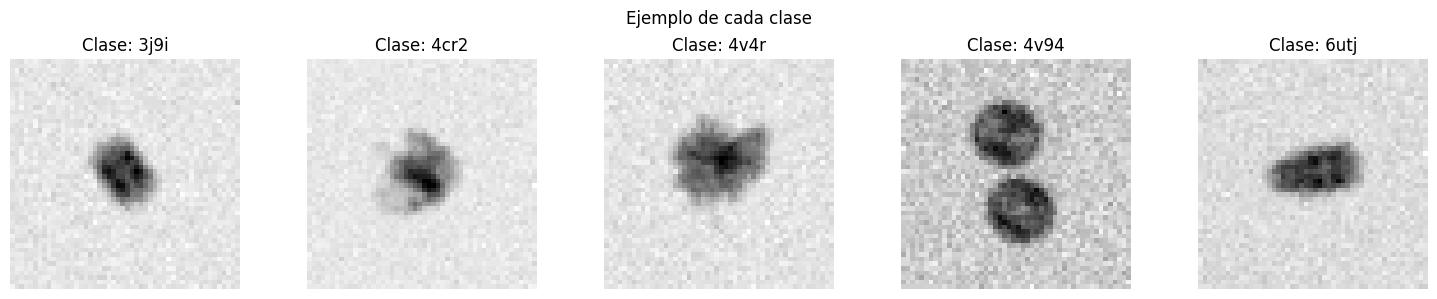

In [16]:
# === E1: Cargar imágenes y etiquetas ===

data_dir = "imgs/SNR_high/"

images = []
labels = []
class_names = []

# Recorrer todos los archivos PNG en el directorio
for fname in sorted(os.listdir(data_dir)):
    if fname.endswith(".png"):
        # Extraer nombre de clase del nombre del archivo
        # Formato: nombre_clase_id_particular.png
        parts = fname.split("_")
        class_name = parts[0]   # e.g., '3j9i', '4cr2', etc.

        if class_name not in class_names:
            class_names.append(class_name)

        class_id = class_names.index(class_name)

        # Cargar imagen
        img_path = os.path.join(data_dir, fname)
        img = io.imread(img_path, as_gray=True).astype(np.float32)

        images.append(img)
        labels.append(class_id)

# Convertir a arrays numpy
X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

# Normalizar imágenes al rango [0, 1] si no lo están ya
if X.max() > 1.0:
    X /= 255.0

print(f"Clases encontradas: {class_names}")
print(f"Número de imágenes: {X.shape[0]}")
print(f"Tamaño de la imagen: {X.shape[1]}x{X.shape[2]}")
print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Distribución de clases: {np.bincount(y)}")

# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, cls in enumerate(class_names):
    idx = np.where(y == i)[0][0]
    axes[i].imshow(X[idx], cmap="gray")
    axes[i].set_title(f"Clase: {cls}")
    axes[i].axis('off')
plt.suptitle("Ejemplo de cada clase")
plt.tight_layout()
plt.show()

In [17]:
# === E2: Aleatorizar las imágenes y etiquetas ===

print(f"Datos sin aleatorizar. Primeras 10 etiquetas: {y[:10]}")
X, y = shuffle(X, y, random_state=42)
print(f"Datos aleatorizados. Primeras 10 etiquetas: {y[:10]}")

Datos sin aleatorizar. Primeras 10 etiquetas: [0 0 0 0 0 0 0 0 0 0]
Datos aleatorizados. Primeras 10 etiquetas: [3 0 3 1 1 3 3 1 0 4]


In [18]:
# === E3: Particionar en entrenamiento (80%) y test (20%) ===

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape} imágenes")
print(f"Test: {X_test.shape} imágenes")
print(f"Distribución entrenamiento: {np.bincount(y_train)}")
print(f"Distribución test: {np.bincount(y_test)}")

Entrenamiento: (400, 50, 50) imágenes
Test: (100, 50, 50) imágenes
Distribución entrenamiento: [80 80 80 80 80]
Distribución test: [20 20 20 20 20]


In [19]:
# === E4: Construir MLP baseline ===

num_classes = len(class_names)
input_dim = X_train.shape[1] * X_train.shape[2] # 50*50 = 2500

# Aplanar imágenes para el MLP
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Convertir etiquetas a one-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# Construir el MLP
mlp_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
], name="MLP_baseline")

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

Model: "MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │     1,280,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,453,317 (5.54 MB)

 Trainable params: 1,453,317 (5.54 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# === E5: Número de parámetros del MLP ===

total_params = mlp_model.count_params()
print(f"Total de parámetros entrenables del MLP: {total_params:,}")
print("\nDesglose:")
print(f"    Entrada -> Capa 1: 2500*512 + 512 = {2500*512 + 512:,}")
print(f"    Capa 1 -> Capa 2:  512*256 + 256  = {512*256 + 256:,}")
print(f"    Capa 2 -> Capa 3:  256*128 + 128  = {256*128 + 128:,}")
print(f"    Capa 3 -> Capa 4:  128*64 + 64    = {128*64 + 64:,}")
print(f"    Capa 4 -> Salida:  64*5 + 5       = {64*5 + 5:,}")
print(f"    TOTAL: {2500*512 + 512 + 512*256 + 256 + 256*128 + 128 + 128*64 + 64 + 64*5 + 5:,}")

Total de parámetros entrenables del MLP: 1,453,317

Desglose:
    Entrada -> Capa 1: 2500*512 + 512 = 1,280,512
    Capa 1 -> Capa 2:  512*256 + 256  = 131,328
    Capa 2 -> Capa 3:  256*128 + 128  = 32,896
    Capa 3 -> Capa 4:  128*64 + 64    = 8,256
    Capa 4 -> Salida:  64*5 + 5       = 325
    TOTAL: 1,453,317


In [21]:
# === E6: Entrenar el MLP ===

mlp_history = mlp_model.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_test_flat, y_test_cat),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


I0000 00:00:1771416005.277885  158800 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16463__.19


 1/13 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.1875 - loss: 1.6729

I0000 00:00:1771416006.375228  158804 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16463__.19


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.1850 - loss: 1.9834 - val_accuracy: 0.2000 - val_loss: 1.8323
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2075 - loss: 1.7774 - val_accuracy: 0.2000 - val_loss: 1.9323
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2500 - loss: 1.7042 - val_accuracy: 0.2000 - val_loss: 1.7108
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3100 - loss: 1.6127 - val_accuracy: 0.2100 - val_loss: 1.5697
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3000 - loss: 1.5009 - val_accuracy: 0.3600 - val_loss: 1.5299
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4225 - loss: 1.3839 - val_accuracy: 0.4100 - val_loss: 1.3957
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4975 - loss: 1.2199 - val_accuracy: 0.5100 - val_loss: 1.2039
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5075 - loss: 1.0943 - val_accuracy: 0.3700 - val_loss: 1.3399
E

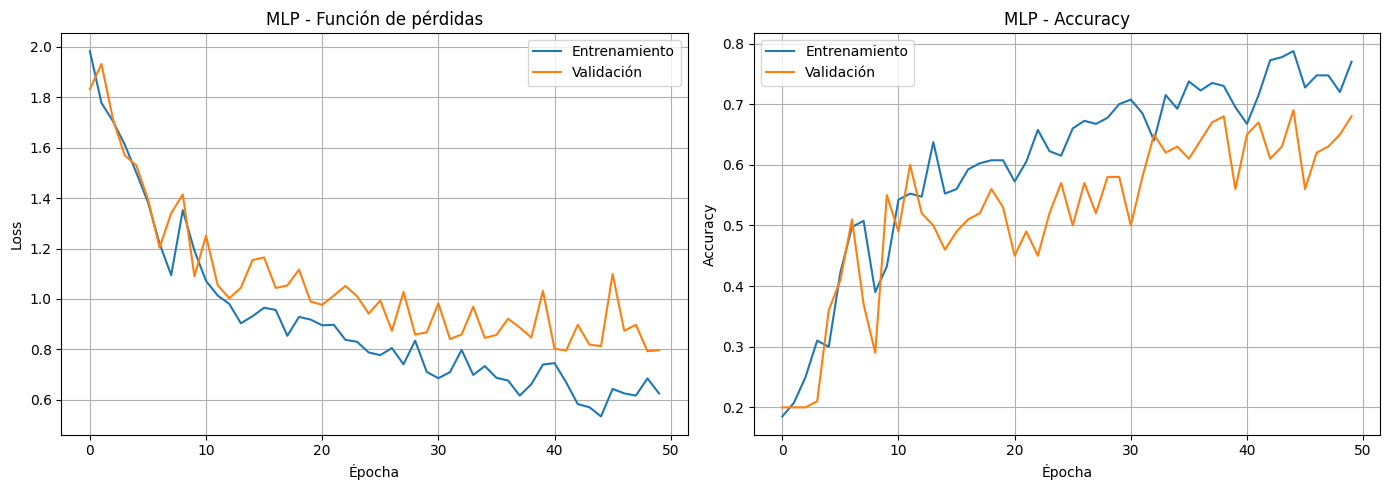

In [22]:
# === E7: Evolución de la función de pérdidas ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(mlp_history.history['loss'], label='Entrenamiento')
axes[0].plot(mlp_history.history['val_loss'], label='Validación')
axes[0].set_title('MLP - Función de pérdidas')
axes[0].set_xlabel('Épocha')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(mlp_history.history['accuracy'], label='Entrenamiento')
axes[1].plot(mlp_history.history['val_accuracy'], label='Validación')
axes[1].set_title('MLP - Accuracy')
axes[1].set_xlabel('Épocha')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [23]:
# === E8: Precisión del MLP ===

mlp_loss, mlp_acc = mlp_model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"Accuracy del MLP en test: {mlp_acc*100:.2f}%")
print(f"Loss del MLP en test: {mlp_loss:.4f}")

Accuracy del MLP en test: 68.00%
Loss del MLP en test: 0.7964


In [24]:
# === E9: Construir CNN + MLP ===

# Añadir dimensión de canal para las capas convolucionales
X_train_cnn = X_train[..., np.newaxis]  # (N, 50, 50, 1)
X_test_cnn = X_test[..., np.newaxis]

cnn_model = keras.Sequential([
    layers.Input(shape=(50, 50, 1)),

    # Bloque convolucional 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Bloque convolucional 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Bloque convolucional 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Aplanar para el MLP
    layers.Flatten(),

    # MLP clasificador
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
], name="CNN_classifier")

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "CNN_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 691,205 (2.64 MB)

 Trainable params: 691,205 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# === E10: Comparar parámetros CNN vs MLP ===

cnn_params = cnn_model.count_params()
mlp_params = mlp_model.count_params()

print(f"Parámetros del MLP: {mlp_params:,}")
print(f"Parámetros de la CNN: {cnn_params:,}")
print(f"Ratio MLP/CNN: {mlp_params/cnn_params:.2f}x")
print(f"\nLa CNN tiene {mlp_params - cnn_params:,} parámetros MENOS que el MLP")

Parámetros del MLP: 1,453,317
Parámetros de la CNN: 691,205
Ratio MLP/CNN: 2.10x

La CNN tiene 762,112 parámetros MENOS que el MLP


Epoch 1/50


I0000 00:00:1771416013.490781  158802 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23765__.44


 1/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.2188 - loss: 1.6045

I0000 00:00:1771416014.826570  158802 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23765__.44


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.1800 - loss: 1.6220 - val_accuracy: 0.2200 - val_loss: 1.6073
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2375 - loss: 1.6072 - val_accuracy: 0.4300 - val_loss: 1.5997
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3225 - loss: 1.5865 - val_accuracy: 0.5300 - val_loss: 1.5488
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4325 - loss: 1.4569 - val_accuracy: 0.4200 - val_loss: 1.3314
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4950 - loss: 1.1946 - val_accuracy: 0.5300 - val_loss: 1.1613
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5850 - loss: 1.0179 - val_accuracy: 0.5800 - val_loss: 1.0870
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6350 - loss: 0.9227 - val_accuracy: 0.5700 - val_loss: 1.0428
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6450 - loss: 0.8746 - val_accuracy: 0.6000 - val_loss: 1.0126
E

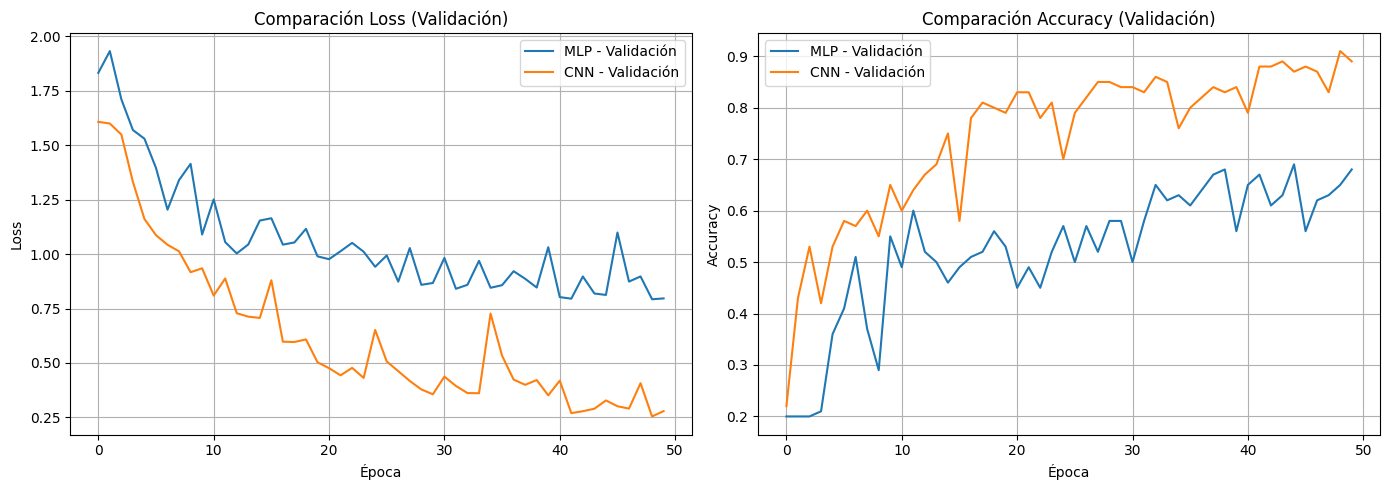

In [26]:
# === E11: Entrenar la CNN y comparar con MLP ===

cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=50,
    batch_size=32,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print("=" * 50)
print(f"Precisión MLP en test: {mlp_acc*100:.2f}%")
print(f"Precisión CNN en test: {cnn_acc*100:.2f}%")
print(f"Mejora: {(cnn_acc - mlp_acc)*100:.2f} puntos porcentuales")
print("=" * 50)

# Gráficas comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_history.history['val_loss'], label='MLP - Validación')
axes[0].plot(cnn_history.history['val_loss'], label='CNN - Validación')
axes[0].set_title('Comparación Loss (Validación)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mlp_history.history['val_accuracy'], label='MLP - Validación')
axes[1].plot(cnn_history.history['val_accuracy'], label='CNN - Validación')
axes[1].set_title('Comparación Accuracy (Validación)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


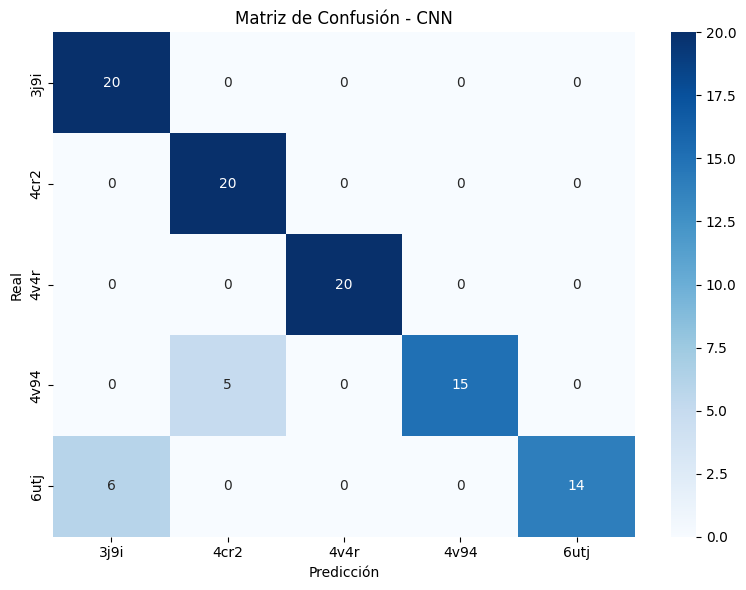

Informe de clasificación:
              precision    recall  f1-score   support

        3j9i       0.77      1.00      0.87        20
        4cr2       0.80      1.00      0.89        20
        4v4r       1.00      1.00      1.00        20
        4v94       1.00      0.75      0.86        20
        6utj       1.00      0.70      0.82        20

    accuracy                           0.89       100
   macro avg       0.91      0.89      0.89       100
weighted avg       0.91      0.89      0.89       100



In [27]:
# === E12: Matriz de confusión ===

y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - CNN')
plt.tight_layout()
plt.show()

print("Informe de clasificación:")
print(classification_report(y_test, y_pred, target_names=class_names))

Las dos clases con mayor confusión mutua: '3j9i' y '6utj'
Confusiones: 3j9i -> 6utj: 0, 6utj -> 3j9i: 6
Total confusión mutua: 6

Estas clases pueden confundirse porque las proyecciones 2D de estos complejos
moleculares a ciertas orientaciones pueden producir imágenes visualmente similares.


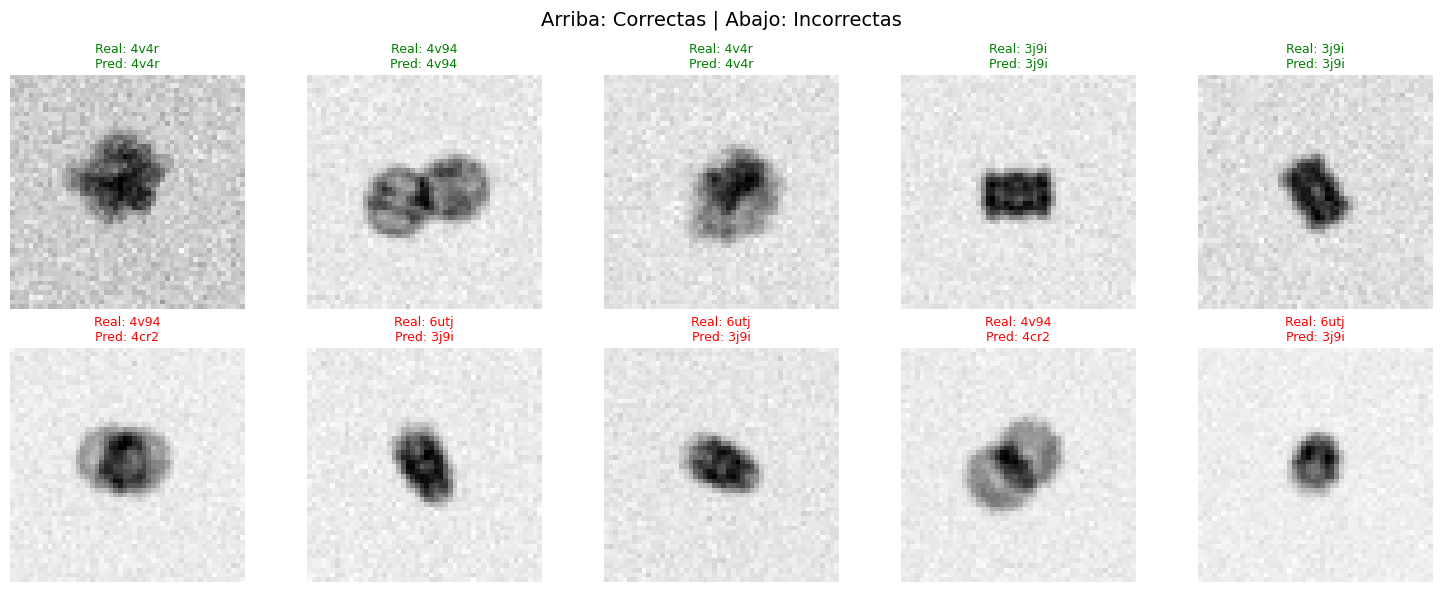

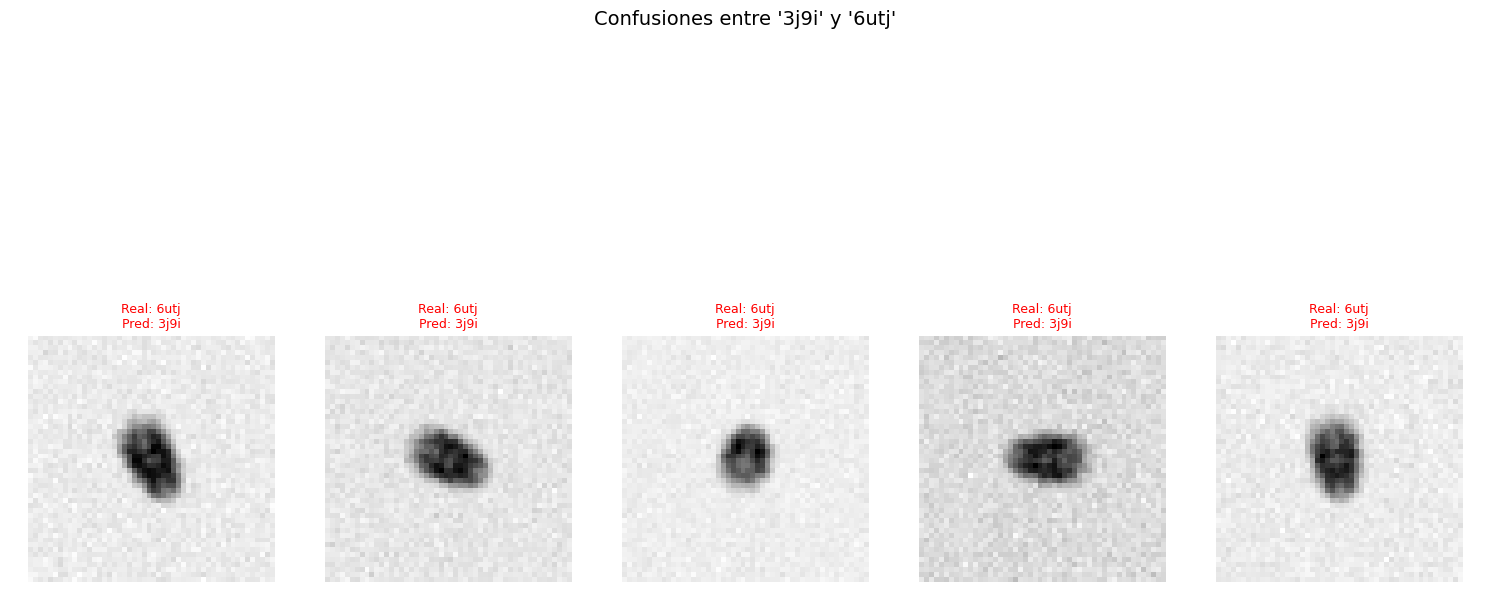

In [28]:
# # === E13: Análisis de confusión y visualización ===

# Encontrar las dos clases con mayor confusión mutua
# Sumamos la confusión en ambas direcciones (i->j + j->i) excluyendo la diagonal
n_classes = len(class_names)
max_confusion = 0
confused_pair = (0, 0)

for i in range(n_classes):
    for j in range(i+1, n_classes):
        mutual_confusion = cm[i, j] + cm[j, i]
        if mutual_confusion > max_confusion:
            max_confusion = mutual_confusion
            confused_pair = (i, j)

c1, c2 = confused_pair
print(f"Las dos clases con mayor confusión mutua: '{class_names[c1]}' y '{class_names[c2]}'")
print(f"Confusiones: {class_names[c1]} -> {class_names[c2]}: {cm[c1,c2]}, "
      f"{class_names[c2]} -> {class_names[c1]}: {cm[c2,c1]}")
print(f"Total confusión mutua: {max_confusion}")
print("\nEstas clases pueden confundirse porque las proyecciones 2D de estos complejos")
print("moleculares a ciertas orientaciones pueden producir imágenes visualmente similares.")

# Visualizar clasificaciones correctas e incorrectas
correct_mask = (y_pred == y_test)
incorrect_mask = ~correct_mask

correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

# Mostrar imágenes correctamente clasificadas
n_show = min(5, len(correct_indices))
fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))

fig.suptitle("Arriba: Correctas | Abajo: Incorrectas", fontsize=14)

for i in range(n_show):
    idx = correct_indices[i]
    axes[0, i].imshow(X_test[idx], cmap='gray')
    axes[0, i].set_title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", 
                          fontsize=9, color='green')
    axes[0, i].axis('off')

# Mostrar imágenes incorrectamente clasificadas
n_show_inc = min(n_show, len(incorrect_indices))
for i in range(n_show_inc):
    idx = incorrect_indices[i]
    axes[1, i].imshow(X_test[idx], cmap='gray')
    axes[1, i].set_title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", 
                          fontsize=9, color='red')
    axes[1, i].axis('off')

# Ocultar ejes sobrantes si hay menos incorrectas que correctas
for i in range(n_show_inc, n_show):
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Mostrar específicamente confusiones entre el par más confuso
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f"Confusiones entre '{class_names[c1]}' y '{class_names[c2]}'", fontsize=14)

# c1 clasificadas como c2
mask_c1_as_c2 = (y_test == c1) & (y_pred == c2)
indices_c1_as_c2 = np.where(mask_c1_as_c2)[0]
for i in range(min(5, len(indices_c1_as_c2))):
    axes[0, i].imshow(X_test[indices_c1_as_c2[i]], cmap='gray')
    axes[0, i].set_title(f"Real: {class_names[c1]}\nPred: {class_names[c2]}", fontsize=9, color='red')
    axes[0, i].axis('off')

# c2 clasificadas como c1
mask_c2_as_c1 = (y_test == c2) & (y_pred == c1)
indices_c2_as_c1 = np.where(mask_c2_as_c1)[0]
for i in range(min(5, len(indices_c2_as_c1))):
    axes[1, i].imshow(X_test[indices_c2_as_c1[i]], cmap='gray')
    axes[1, i].set_title(f"Real: {class_names[c2]}\nPred: {class_names[c1]}", fontsize=9, color='red')
    axes[1, i].axis('off')

# Ocultar ejes vacíos
for row in range(2):
    n_filled = len(indices_c1_as_c2) if row == 0 else len(indices_c2_as_c1)
    for i in range(min(5, n_filled), 5):
        axes[row, i].axis('off')

plt.tight_layout()
plt.show()